In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
import pickle
from collections import defaultdict

In [2]:
# --- Global rcParams ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 22,       # Axis labels fontsize
    "xtick.labelsize": 18,      # X tick labels fontsize
    "ytick.labelsize": 18,      # Y tick labels fontsize
    "xtick.direction": "in",    # X ticks inward
    "ytick.direction": "in",    # Y ticks inward
    "xtick.top": True,          # Show ticks on top
    "ytick.right": True,        # Show ticks on right
    #"axes.grid": True,          # Enable grid
    #"grid.linestyle": "--",     # Grid style
    #"grid.alpha": 0.4           # Grid transparency
})

In [3]:
# --- Load pickled dictionary ---
with open("parametric_curves_creep.pkl", "rb") as f:
    parametric_curves_creep = pickle.load(f)

In [4]:
# --- Display keys ---
print("Keys:")
for k in parametric_curves_creep.keys():
    print(k)

Keys:
('-6.6666665e+14', '1000.00000000')
('-6.6666666e+16', '1000.00000000')
('-6.6666666e+18', '1000.00000000')
('-9.9502486e+12', '1000.00000000')
('-9.9502488e+14', '1000.00000000')
('-9.9502488e+16', '1000.00000000')
('-9.9994998e+10', '1000.00000000')
('-9.9995e+12', '1000.00000000')
('-9.9995e+14', '1000.00000000')
('-6.6666665e+12', '1000.00000000')
('-6.6666666e+14', '1000.00000000')
('-9.9502486e+10', '1000.00000000')
('-9.9502488e+12', '1000.00000000')
('-9.9994998e+08', '1000.00000000')
('-9.9995e+10', '1000.00000000')
('-6.6666665e+10', '1000.00000000')
('-6.6666666e+12', '1000.00000000')
('-9.9502486e+08', '1000.00000000')
('-9.9502488e+10', '1000.00000000')
('-9999499.8', '1000.00000000')
('-9.9995e+08', '1000.00000000')
('-6.6666665e+08', '1000.00000000')
('-6.6666666e+10', '1000.00000000')


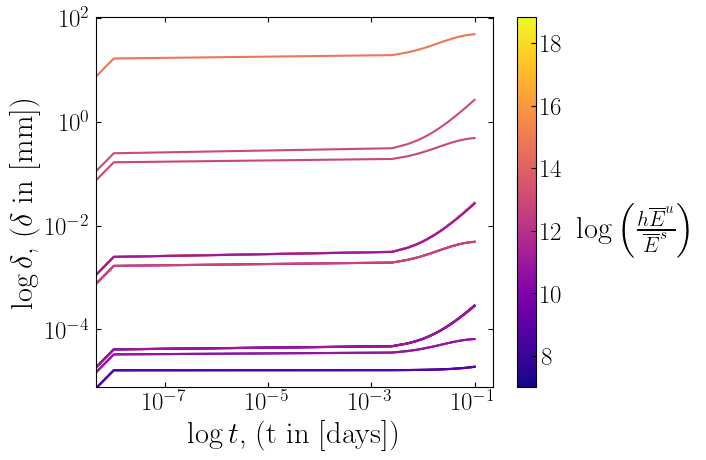

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys())]
a_min, a_max = min(a_vals), max(a_vals)
parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:]}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, displacement, color=color, label=f"a={a_float:.9g}")

ax.set_xscale("log")
ax.set_xlabel("$\\log t$, (t in [days])")

ax.set_yscale("log")      # ← make y-axis logarithmic
ax.set_ylabel("$\\log\\delta$, ($\\delta$ in  [mm])", color='k')  

#ax.set_ylabel(r"$\delta$ [mm]", color='k')

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

#cbar = plt.colorbar(sm, ax=ax)
#cbar.set_label("a-value (log scale)")

# keep only about 6 ticks
#cbar.locator = LogLocator(base=10.0, numticks=6)
#cbar.update_ticks()

## more ticks in between powers of 10
#cbar.locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=15)
#cbar.update_ticks()
# ✅ exactly 6 ticks between min and max, log-spaced
tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{val:.1e}" for val in tick_vals])  # scientific notation

# format with scientific notation but keep decimals
##cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#formatter = LogFormatterSciNotation(base=10, labelOnlyBase=False)
#cbar.ax.yaxis.set_major_formatter(formatter)
##cbar.ax.yaxis.get_major_formatter().set_scientific(True)
#cbar.ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_delta_a.pdf", bbox_inches="tight")
plt.show()

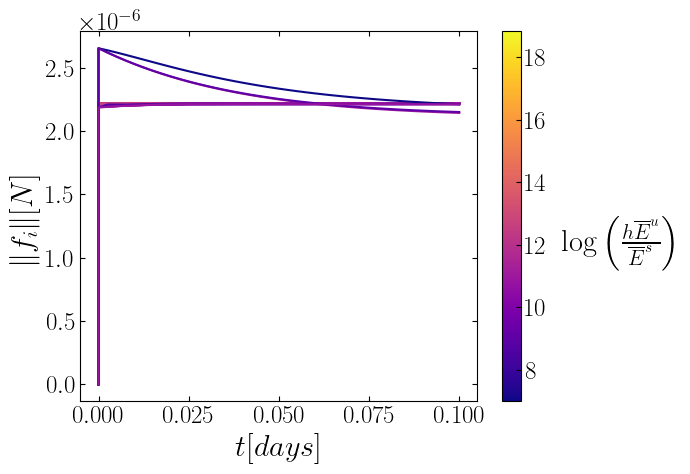

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys())]
a_min, a_max = min(a_vals), max(a_vals)
parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:]}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, force, color=color, label=f"a={a_float:.9g}")

#ax.set_xscale("log")
#ax.set_xlabel("$\\log t$, (t in [days])")

#ax.set_xscale("log")
ax.set_xlabel("$t [days]$")

#ax.set_yscale("log")      # ← make y-axis logarithmic
#ax.set_ylabel("$\\log \\|f_i\\|$, ($\\|f_i\\|$ in  [N])", color='k')  
ax.set_ylabel("$ \\|f_i\\| [N]$", color='k')  

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

#cbar = plt.colorbar(sm, ax=ax)
#cbar.set_label("a-value (log scale)")

# keep only about 6 ticks
#cbar.locator = LogLocator(base=10.0, numticks=6)
#cbar.update_ticks()

## more ticks in between powers of 10
#cbar.locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=15)
#cbar.update_ticks()
# ✅ exactly 6 ticks between min and max, log-spaced
tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{val:.1e}" for val in tick_vals])  # scientific notation

# format with scientific notation but keep decimals
##cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#formatter = LogFormatterSciNotation(base=10, labelOnlyBase=False)
#cbar.ax.yaxis.set_major_formatter(formatter)
##cbar.ax.yaxis.get_major_formatter().set_scientific(True)
#cbar.ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_force_a.pdf", bbox_inches="tight")
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_211809/1470056008.py:43: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel("$\\|\sigma_{ij}\\|$  [MPa]", color='k')


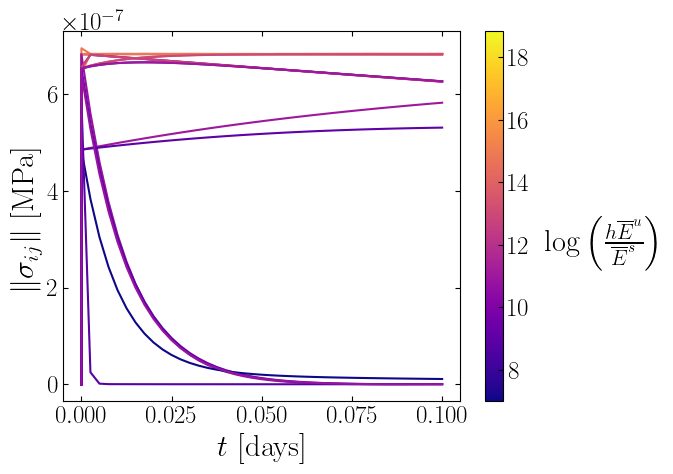

In [94]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
#from matplotlib.ticker import LogFormatterMathText
from matplotlib.ticker import FuncFormatter

def sci_mathtext(x, pos):
    # format with scientific notation
    s = f"{x:.2e}"   # adjust decimals as needed
    base, exp = s.split("e")
    exp = int(exp)
    return rf"${exp}$"#rf"${base} \times 10^{{{exp}}}$"

# --- extract all a-values as floats
a_vals = [np.abs(float(key[0])) for key in list(parametric_curves_creep.keys())]
a_min, a_max = min(a_vals), max(a_vals)
parametric_curves_creep_keys =list( parametric_curves_creep.keys())

select_parametric_curves_creep_dict = {k: parametric_curves_creep[k] for k in parametric_curves_creep_keys[:]}
# --- continuous colormap
cmap = plt.colormaps["plasma"]
#norm = plt.Normalize(vmin=a_min, vmax=a_max)
norm = LogNorm(vmin=a_min, vmax=a_max)

fig, ax = plt.subplots()

# --- loop and plot each curve with its own color
for (a, b), data_entry in select_parametric_curves_creep_dict.items():
    a_float = np.abs(float(a))  # force numeric
    color = cmap(norm(a_float))
    time, displacement, force, stress = data_entry
    ax.plot(time, stress, color=color, label=f"a={a_float:.9g}")

#ax.set_xscale("log")
#ax.set_xlabel("$\\log t$, (t in [days])")
ax.set_xlabel("$t$ [days]")


#ax.set_yscale("log")      # ← make y-axis logarithmic
#ax.set_ylabel("$\\log \\|\sigma_{ij}\\|$, ($\\|\sigma_{ij}\\|$ in  [N])", color='k')  
ax.set_ylabel("$\\|\sigma_{ij}\\|$  [MPa]", color='k')  

#ax.set_ylabel(r"$\delta$ [mm]", color='k')

# --- scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

#cbar = plt.colorbar(sm, ax=ax)
#cbar.set_label("a-value (log scale)")

# keep only about 6 ticks
#cbar.locator = LogLocator(base=10.0, numticks=6)
#cbar.update_ticks()

## more ticks in between powers of 10
#cbar.locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=15)
#cbar.update_ticks()
# ✅ exactly 6 ticks between min and max, log-spaced
tick_vals = np.logspace(np.log10(a_min), np.log10(a_max), 6)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f"{val:.1e}" for val in tick_vals])  # scientific notation

# format with scientific notation but keep decimals
##cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#formatter = LogFormatterSciNotation(base=10, labelOnlyBase=False)
#cbar.ax.yaxis.set_major_formatter(formatter)
##cbar.ax.yaxis.get_major_formatter().set_scientific(True)
#cbar.ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("$\\log\\left(\\frac{h\\overline{E}^u}{\\overline{E}^s}\\right)$", rotation=0,labelpad=10,
    x=1.1,
    ha='left')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_mathtext))

plt.show()

# save to PDF
fig.savefig("parametric_curves_creep_surface_stress_a.pdf", bbox_inches="tight")
plt.show()